### KIKO_Real-Time Detection and Filtering of Abusive Content

Feature extraction


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df1 = pd.read_csv(r"D:\ML CODES\IBM\Train_Cleaned\Airline_train_cleaned.csv")
df2 = pd.read_csv(r"D:\ML CODES\IBM\Train_Cleaned\text.tweeet_cleaned.csv")
df3 = pd.read_csv(r"D:\ML CODES\IBM\Train_Cleaned\train_cleaned.csv")


df = pd.concat([df1, df2, df3], ignore_index=True)

In [45]:
df.head()

,sentiment,text
0,neutral,What said
1,positive,plus youve added commercials to the experienc...
2,neutral,I didnt today Must mean I need to take anothe...
3,negative,its really aggressive to blast obnoxious ente...
4,negative,and its a really big bad thing about it


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77983 entries, 0 to 77982
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  77983 non-null  object
 1   text       77981 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [47]:
print(df['sentiment'].value_counts())

sentiment
positive    41429
negative    30380
neutral      6174
Name: count, dtype: int64


In [48]:
df.duplicated().sum()

195

In [49]:
df.drop_duplicates(inplace=True)

In [50]:
df.dropna(inplace=True)

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report , ConfusionMatrixDisplay as cmd

In [52]:
x=df['text']
y=df['sentiment']

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42,stratify=y )

In [54]:
pipeline2 = Pipeline([
    ('vector', TfidfVectorizer(ngram_range=(1,3),min_df=20,max_df=0.6)),
    ('clf', LinearSVC(max_iter=50000, random_state=42)),
    
])

param_grid = {
    'clf__C': [0.1,0.2,0.5,0.3,0.4],
    'clf__class_weight': ['balanced'],

}
grid_search = GridSearchCV(pipeline2, param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)
y_pred = grid_search.predict(x_test)


print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters: {'clf__C': 0.3, 'clf__class_weight': 'balanced'}
Best Cross-Validation Score: 0.8865
Test Accuracy: 0.8906

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.91      0.90      9112
     neutral       0.47      0.53      0.50      1827
    positive       0.96      0.93      0.94     12398

    accuracy                           0.89     23337
   macro avg       0.78      0.79      0.78     23337
weighted avg       0.90      0.89      0.89     23337



In [55]:

# pipeline = Pipeline([
#     ('vector', TfidfVectorizer(ngram_range=(1,3),min_df=5,max_df=0.7)),
#     ('clf', LogisticRegression(max_iter=50000, n_jobs=-1)),
    
# ])

# pipeline.fit(x_train, y_train)
# y_pred = pipeline.predict(x_test)



# print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# print("\nClassification Report:\n")
# print(classification_report(y_test, y_pred))

In [56]:
# Quick audit of available cleaned training files
import glob
from pathlib import Path

for fp in sorted(glob.glob(r'D:\ML CODES\IBM\Train_Cleaned\*.csv')):
    name = Path(fp).name
    try:
        t = pd.read_csv(fp)
        cols = list(t.columns)
        if {'text', 'sentiment'}.issubset(t.columns):
            vc = t['sentiment'].astype(str).str.lower().value_counts().head(5).to_dict()
            print(f"{name:30} rows={len(t):7d}  labels={vc}")
        else:
            print(f"{name:30} rows={len(t):7d}  columns={cols}")
    except Exception as e:
        print(name, '->', e)

Airline_train_cleaned.csv      rows=  14452  labels={'negative': 9087, 'neutral': 3067, 'positive': 2298}
IMDB_Dataset_cleaned.csv       rows=  49582  columns=['review', 'sentiment']
Sentiment_train_cleaned.csv    rows=    708  columns=['Sentiment', 'Text']
text.tweeet_cleaned.csv        rows=   3531  labels={'neutral': 1428, 'positive': 1102, 'negative': 1001}
train_cleaned.csv              rows=  60000  labels={'positive': 38029, 'negative': 20292, 'neutral': 1679}
train_tweet_cleaned.csv        rows=  27480  labels={'neutral': 11117, 'positive': 8582, 'negative': 7781}


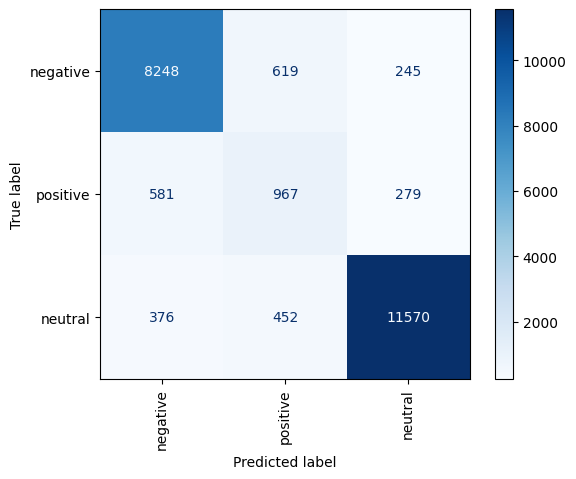

In [57]:
cmd.from_estimator(grid_search.best_estimator_,x_test,y_test, display_labels=['negative','positive','neutral'],xticks_rotation='vertical',cmap=plt.cm.Blues)

In [58]:
def predict_text(text):
    vec = grid_search.best_estimator_.named_steps['vector'].transform([text])   # TF-IDF transform
    pred = grid_search.best_estimator_.named_steps['clf'].predict(vec)[0]
    return pred


In [59]:
print(predict_text("This stream is amazing bro"))
print(predict_text("You are so dumb"))
print(predict_text("It is okay I guess"))

positive
negative
neutral


In [60]:
print(predict_text("not bad"))
print(predict_text("not good"))
print(predict_text("meh"))
print(predict_text("average stream"))
print(predict_text("you are not smart"))

negative
negative
neutral
neutral
negative


In [61]:
import pickle

pickle.dump(grid_search.best_estimator_.named_steps['clf'], open("model.pkl", "wb"))
pickle.dump(grid_search.best_estimator_.named_steps['vector'], open("vector.pkl", "wb"))